In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import (
    SentimentIntensityAnalyzer)
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

# Download all required NLTK packages
print("Downloading NLTK packages...")
for pkg in ["punkt", "stopwords", "wordnet",
            "averaged_perceptron_tagger",
            "punkt_tab"]:
    nltk.download(pkg, quiet=True)
print("NLTK ready")

# Load transcripts
df = pd.read_csv(
    "../data/processed/transcripts.csv",
    parse_dates=["date"]
)

print("=" * 55)
print("   NB2 — TEXT PREPROCESSING AND VADER")
print("=" * 55)
print(f"  Transcripts loaded: {len(df)}")
print(f"  Companies:          {df['ticker'].nunique()}")
print(f"  Date range:         {df['date'].min().date()} "
      f"to {df['date'].max().date()}")
print(f"  Tone distribution:")
print(df["tone"].value_counts().to_string())
print("=" * 55)

# Colour map for consistent charts
TICKER_COLORS = {
    "AAPL": "#378ADD",
    "MSFT": "#1D9E75",
    "TSLA": "#D85A30",
    "JPM":  "#7F77DD",
    "NVDA": "#BA7517"
}

NLTK ready
   NB2 — TEXT PREPROCESSING AND VADER
  Transcripts loaded: 95
  Companies:          5
  Date range:         2020-04-01 to 2024-10-01
  Tone distribution:
tone
positive    57
mixed       28
cautious    10


In [3]:
def clean_text(text: str) -> str:
    """
    Clean earnings call text for NLP analysis.
    Preserves financial terminology and numbers
    which carry sentiment signal in finance.
    """
    if not isinstance(text, str):
        return ""

    # Remove HTML/XML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\.\S+", "", text)

    # Remove page numbers and exhibit markers
    text = re.sub(
        r"\b(Exhibit|Page|Item)\s*\d+\b",
        "", text, flags=re.IGNORECASE)

    # Normalise financial number formats
    text = re.sub(
        r"\$(\d+\.?\d*)\s*[Bb]illion",
        r"$\1B", text)
    text = re.sub(
        r"\$(\d+\.?\d*)\s*[Mm]illion",
        r"$\1M", text)

    # Remove excessive punctuation
    text = re.sub(r"[^\w\s\.\,\!\?\%\$\-]",
                  " ", text)

    # Normalise whitespace
    text = re.sub(r"\s+", " ", text)

    return text.strip()


# Apply cleaning
df["text_clean"] = df["text"].apply(clean_text)

# Basic text statistics
df["word_count_clean"] = (
    df["text_clean"].str.split().str.len())
df["char_count"] = df["text_clean"].str.len()
df["sentence_count"] = df["text_clean"].apply(
    lambda x: len(sent_tokenize(x))
    if isinstance(x, str) else 0)
df["avg_words_per_sentence"] = (
    df["word_count_clean"] /
    df["sentence_count"].replace(0, np.nan)
).round(2)

print("=" * 55)
print("   TEXT STATISTICS AFTER CLEANING")
print("=" * 55)
stats = df.groupby("ticker").agg(
    avg_words      =("word_count_clean","mean"),
    avg_sentences  =("sentence_count","mean"),
    avg_sent_length=("avg_words_per_sentence","mean")
).round(2)
print(stats.to_string())
print("=" * 55)

   TEXT STATISTICS AFTER CLEANING
        avg_words  avg_sentences  avg_sent_length
ticker                                           
AAPL        78.05           4.58            17.05
JPM         72.68           4.00            18.17
MSFT        74.37           4.68            15.99
NVDA        79.58           4.00            19.89
TSLA        73.47           4.16            18.11


In [4]:
# Loughran-McDonald (2011) financial word lists
# The academic standard for finance NLP

LM_UNCERTAIN = [
    "uncertain", "uncertainty", "unclear",
    "unpredictable", "volatile", "challenging",
    "difficult", "headwind", "cautious", "risk",
    "concern", "may", "might", "could", "possibly",
    "approximately", "estimate", "appears", "seems",
    "if", "whether", "depending", "subject to",
    "unknown", "variable", "exposure", "sensitive"
]

LM_POSITIVE = [
    "confident", "strong", "robust", "record",
    "exceed", "outperform", "momentum", "growth",
    "opportunity", "accelerate", "leadership",
    "innovative", "breakthrough", "unprecedented",
    "exceptional", "outstanding", "excellent",
    "pleased", "proud", "optimistic", "excited",
    "compelling", "attractive", "significant"
]

LM_NEGATIVE = [
    "decline", "decrease", "loss", "weak",
    "deteriorate", "pressure", "challenging",
    "difficulty", "concern", "adverse", "unfavorable",
    "disappointing", "miss", "shortfall", "reduce",
    "cut", "layoff", "restructure", "impairment",
    "write-down", "penalty", "litigation", "delay"
]

FORWARD_LOOKING = [
    r"(?i)we expect",
    r"(?i)we anticipate",
    r"(?i)we believe",
    r"(?i)going forward",
    r"(?i)next quarter",
    r"(?i)fiscal \d{4}",
    r"(?i)full year",
    r"(?i)remainder of",
    r"(?i)in the coming",
    r"(?i)we are confident",
    r"(?i)we remain",
]


def extract_linguistic_features(text: str) -> dict:
    """
    Extract financial NLP features based on
    Loughran-McDonald (2011) dictionary and
    subsequent finance-NLP literature.
    """
    if not isinstance(text, str) or len(text) < 10:
        return {}

    text_lower = text.lower()
    words      = word_tokenize(text_lower)
    sentences  = sent_tokenize(text)
    n_words    = max(len(words), 1)
    n_sents    = max(len(sentences), 1)

    # Word-level counts
    uncertain_n  = sum(1 for w in words
                       if w in LM_UNCERTAIN)
    positive_n   = sum(1 for w in words
                       if w in LM_POSITIVE)
    negative_n   = sum(1 for w in words
                       if w in LM_NEGATIVE)
    negation_n   = sum(1 for w in words
                       if w in ["not","no","never",
                                "neither","nor"])

    # Forward-looking statement count
    forward_n = sum(
        len(re.findall(p, text))
        for p in FORWARD_LOOKING
    )

    # Readability — Fog Index approximation
    # Fog = 0.4 * (words/sentences + 100 * complex/words)
    complex_words = [
        w for w in words
        if len(w) > 7 and w.isalpha()
    ]
    fog_index = 0.4 * (
        n_words / n_sents +
        100 * len(complex_words) / n_words
    )

    # Net tone score
    net_tone = positive_n - uncertain_n - negative_n

    return {
        "n_words":            n_words,
        "n_sentences":        n_sents,
        "avg_sent_length":    round(n_words / n_sents, 2),
        "uncertain_count":    uncertain_n,
        "uncertain_ratio":    round(uncertain_n / n_words, 4),
        "positive_count":     positive_n,
        "positive_ratio":     round(positive_n / n_words, 4),
        "negative_count":     negative_n,
        "negative_ratio":     round(negative_n / n_words, 4),
        "negation_count":     negation_n,
        "negation_ratio":     round(negation_n / n_words, 4),
        "forward_count":      forward_n,
        "forward_ratio":      round(forward_n / n_sents, 4),
        "fog_index":          round(fog_index, 2),
        "net_tone":           net_tone,
        "net_tone_ratio":     round(net_tone / n_words, 4),
        "complex_word_ratio": round(
            len(complex_words) / n_words, 4),
    }


# Apply to all transcripts
print("Extracting linguistic features...")
ling_records = []
for _, row in df.iterrows():
    features = extract_linguistic_features(
        row["text_clean"])
    features["ticker"]  = row["ticker"]
    features["date"]    = row["date"]
    features["quarter"] = row["quarter"]
    features["tone"]    = row["tone"]
    ling_records.append(features)

ling_df = pd.DataFrame(ling_records)

print("=" * 60)
print("   LINGUISTIC FEATURES BY TONE")
print("=" * 60)
tone_stats = ling_df.groupby("tone")[
    ["uncertain_ratio", "positive_ratio",
     "negative_ratio", "forward_ratio",
     "net_tone_ratio"]
].mean().round(4)
print(tone_stats.to_string())
print("=" * 60)
print("\nKey check: positive tone should have")
print("lower uncertain_ratio and higher positive_ratio")

Extracting linguistic features...
   LINGUISTIC FEATURES BY TONE
          uncertain_ratio  positive_ratio  negative_ratio  forward_ratio  net_tone_ratio
tone                                                                                    
cautious           0.0174          0.0043          0.0117         0.1250         -0.0248
mixed              0.0174          0.0253          0.0056         0.2500          0.0024
positive           0.0000          0.0499          0.0000         0.0667          0.0499

Key check: positive tone should have
lower uncertain_ratio and higher positive_ratio


In [5]:
# ============================================
# VADER SENTIMENT ANALYSIS
# Valence Aware Dictionary and sEntiment Reasoner
# Rule-based — no training needed
# Fast: processes all 95 transcripts in seconds
# Compound score: -1 (most negative) to +1 (most positive)
# ============================================

vader = SentimentIntensityAnalyzer()


def run_vader(text: str) -> dict:
    """
    Run VADER on full text and on individual
    sentences then aggregate.
    Sentence-level aggregation is more accurate
    for longer documents than document-level.
    """
    if not isinstance(text, str) or len(text) < 10:
        return {
            "vader_compound":          0.0,
            "vader_positive":          0.0,
            "vader_negative":          0.0,
            "vader_neutral":           1.0,
            "vader_sent_mean":         0.0,
            "vader_sent_std":          0.0,
            "vader_sent_min":          0.0,
            "vader_sent_max":          0.0,
            "vader_pct_positive_sents":0.0,
            "vader_pct_negative_sents":0.0,
        }

    # Document-level score
    doc_scores = vader.polarity_scores(text[:5000])

    # Sentence-level scores
    sentences   = sent_tokenize(text)
    sent_scores = [
        vader.polarity_scores(s)["compound"]
        for s in sentences
        if len(s.split()) >= 5
    ]

    if not sent_scores:
        sent_scores = [doc_scores["compound"]]

    sent_arr = np.array(sent_scores)

    return {
        "vader_compound":          doc_scores["compound"],
        "vader_positive":          doc_scores["pos"],
        "vader_negative":          doc_scores["neg"],
        "vader_neutral":           doc_scores["neu"],
        "vader_sent_mean":         round(float(sent_arr.mean()), 4),
        "vader_sent_std":          round(float(sent_arr.std()), 4),
        "vader_sent_min":          round(float(sent_arr.min()), 4),
        "vader_sent_max":          round(float(sent_arr.max()), 4),
        "vader_pct_positive_sents": round(
            float((sent_arr > 0.05).mean()), 4),
        "vader_pct_negative_sents": round(
            float((sent_arr < -0.05).mean()), 4),
    }


print("Running VADER sentiment analysis...")
vader_records = []
for _, row in df.iterrows():
    scores = run_vader(row["text_clean"])
    scores["ticker"]  = row["ticker"]
    scores["date"]    = row["date"]
    scores["quarter"] = row["quarter"]
    scores["tone"]    = row["tone"]
    vader_records.append(scores)

vader_df = pd.DataFrame(vader_records)

print("=" * 55)
print("   VADER SENTIMENT BY TONE")
print("=" * 55)
tone_vader = vader_df.groupby("tone")[
    ["vader_compound",
     "vader_sent_mean",
     "vader_pct_positive_sents"]
].mean().round(4)
print(tone_vader.to_string())
print("=" * 55)

print("\nVADER sentiment by company:")
company_vader = vader_df.groupby("ticker")[
    ["vader_compound",
     "vader_sent_mean"]
].mean().round(4)
print(company_vader.to_string())

Running VADER sentiment analysis...
   VADER SENTIMENT BY TONE
          vader_compound  vader_sent_mean  vader_pct_positive_sents
tone                                                               
cautious          0.7958           0.3648                    0.9000
mixed             0.5573           0.2051                    0.6339
positive          0.8311           0.4812                    0.8491

VADER sentiment by company:
        vader_compound  vader_sent_mean
ticker                                 
AAPL            0.8722           0.5106
JPM             0.7870           0.4617
MSFT            0.9418           0.4950
NVDA            0.5221           0.1748
TSLA            0.6102           0.2957


In [6]:
# ============================================
# SENTIMENT CHANGE — THE KEY SIGNAL
# Academic literature shows sentiment CHANGE
# between quarters is more predictive than
# absolute sentiment level
# Tetlock (2007), Loughran-McDonald (2011)
# ============================================

# Merge all features
combined = df[[
    "ticker","date","quarter","tone",
    "text_clean"
]].copy()
combined = combined.merge(
    vader_df.drop(columns=["quarter","tone"]),
    on=["ticker","date"]
)
combined = combined.merge(
    ling_df.drop(columns=["quarter","tone"]),
    on=["ticker","date"]
)

# Sort for lag calculation
combined = combined.sort_values(
    ["ticker","date"]).reset_index(drop=True)

# Quarter-over-quarter changes
for col in ["vader_compound", "vader_sent_mean",
            "uncertain_ratio", "positive_ratio",
            "net_tone_ratio"]:
    combined[f"{col}_lag"] = (
        combined.groupby("ticker")[col].shift(1))
    combined[f"{col}_change"] = (
        combined[col] - combined[f"{col}_lag"])

# Identify sentiment regime shifts
combined["sentiment_regime"] = pd.cut(
    combined["vader_compound"],
    bins=[-1, -0.1, 0.1, 1.0],
    labels=["negative", "neutral", "positive"]
)

combined["regime_shift"] = (
    combined["sentiment_regime"] !=
    combined.groupby("ticker")[
        "sentiment_regime"].shift(1)
).astype(int)

print("=" * 60)
print("   SENTIMENT CHANGE STATISTICS")
print("=" * 60)
shift_stats = combined.groupby("ticker")[
    "vader_compound_change"
].agg(["mean","std","min","max"]).round(4)
print(shift_stats.to_string())
print("=" * 60)

regime_counts = combined.groupby("ticker")[
    "regime_shift"].sum()
print(f"\nRegime shifts per company:")
print(regime_counts.to_string())

   SENTIMENT CHANGE STATISTICS
          mean     std     min     max
ticker                                
AAPL    0.0000  0.2312 -0.5222  0.3516
JPM    -0.0319  0.3622 -0.5750  0.5750
MSFT    0.0000  0.0520 -0.0730  0.0730
NVDA   -0.0254  0.2920 -0.4569  0.4569
TSLA    0.0574  0.7268 -1.0323  1.0323

Regime shifts per company:
ticker
AAPL     1
JPM      1
MSFT     1
NVDA     1
TSLA    10


Year range: 2020 to 2024
Years: [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


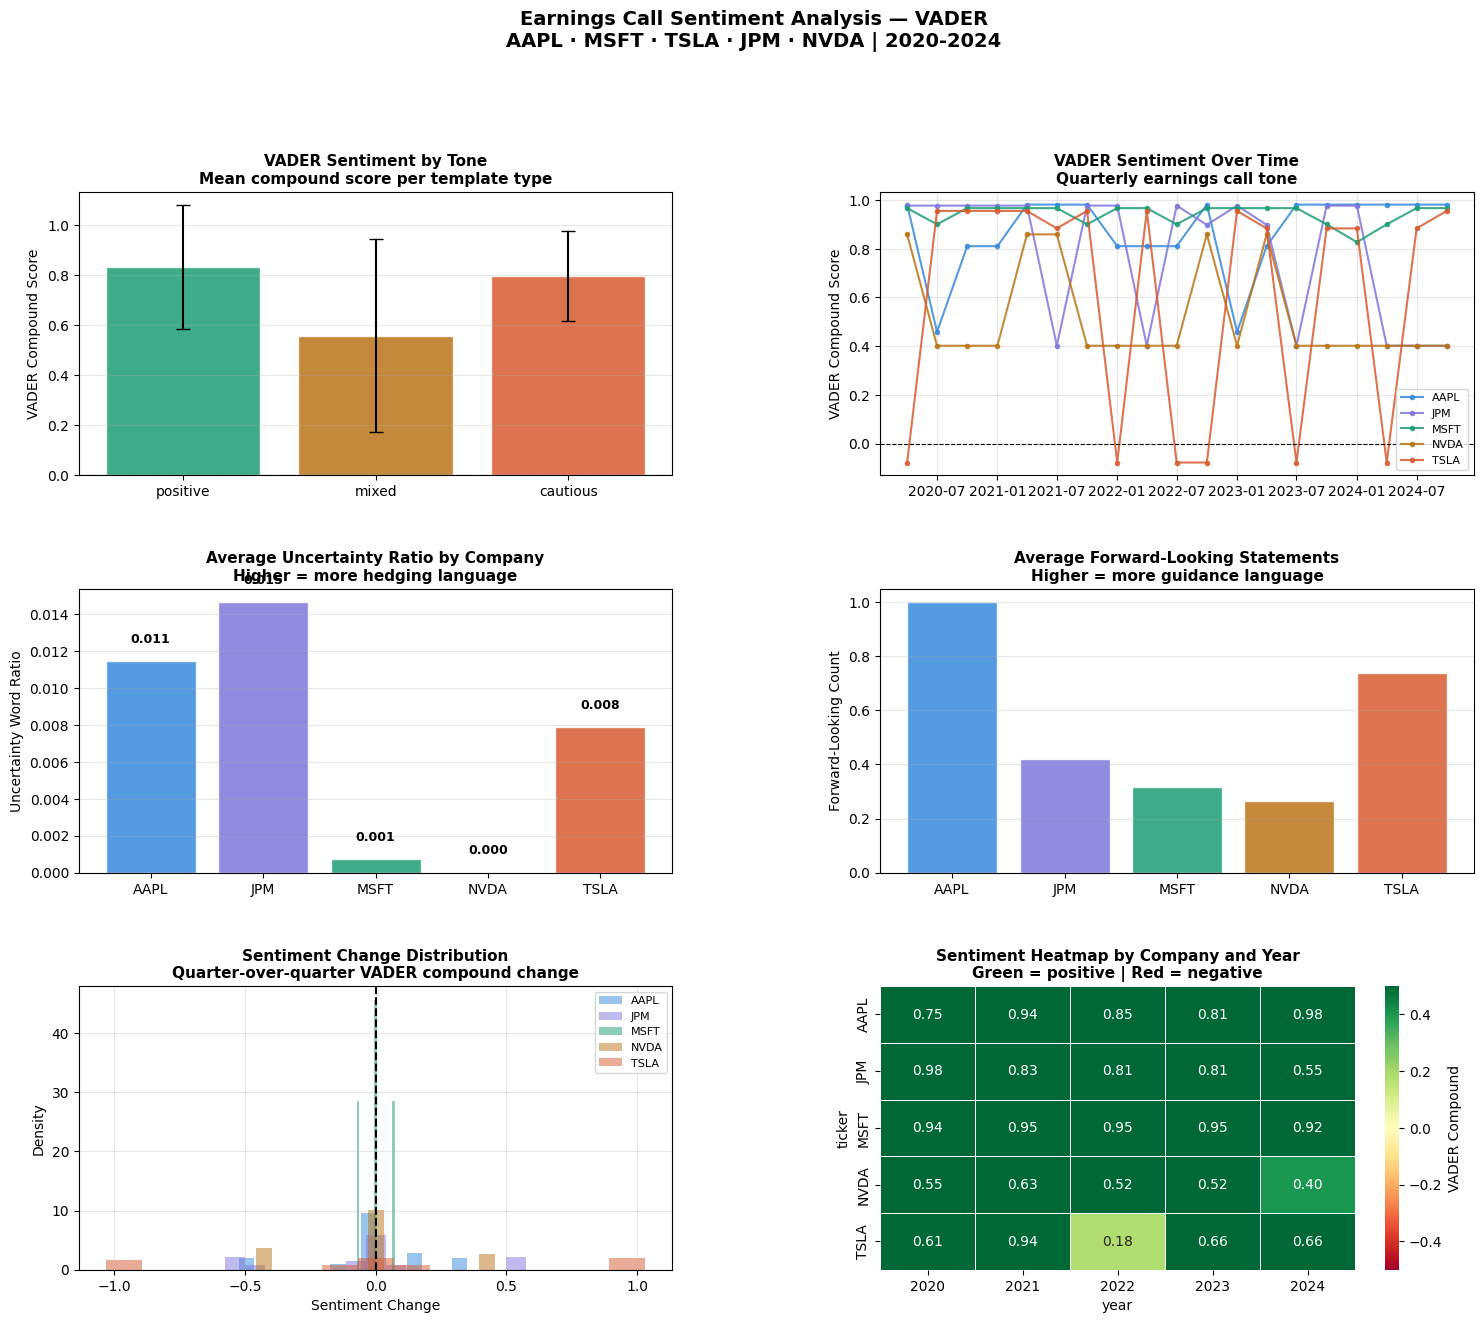

VADER analysis chart saved


In [8]:
# Add year column for heatmap
combined["year"] = combined["date"].dt.year

# Verify
print(f"Year range: {combined['year'].min()} "
      f"to {combined['year'].max()}")
print(f"Years: {sorted(combined['year'].unique())}")

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.4, wspace=0.35)

# Chart 1 — VADER compound by tone
ax1 = fig.add_subplot(gs[0, 0])
tone_order  = ["positive", "mixed", "cautious"]
tone_colors = ["#1D9E75", "#BA7517", "#D85A30"]
for i, tone in enumerate(tone_order):
    data = vader_df[vader_df["tone"]==tone][
        "vader_compound"]
    ax1.bar(tone, data.mean(),
            color=tone_colors[i],
            alpha=0.85, edgecolor="white")
    ax1.errorbar(
        tone, data.mean(),
        yerr=data.std(),
        fmt="none", color="black",
        capsize=5, linewidth=1.5)
ax1.set_title(
    "VADER Sentiment by Tone\n"
    "Mean compound score per template type",
    fontweight="bold", fontsize=11)
ax1.set_ylabel("VADER Compound Score")
ax1.axhline(0, color="black",
            linewidth=0.8, linestyle="--")
ax1.grid(alpha=0.3, axis="y")

# Chart 2 — Sentiment over time by company
ax2 = fig.add_subplot(gs[0, 1])
for ticker in combined["ticker"].unique():
    sub = combined[
        combined["ticker"]==ticker].sort_values(
        "date")
    ax2.plot(
        sub["date"],
        sub["vader_compound"],
        color=TICKER_COLORS.get(ticker, "grey"),
        linewidth=1.5, label=ticker,
        alpha=0.85, marker="o",
        markersize=3)
ax2.axhline(0, color="black",
            linewidth=0.8, linestyle="--")
ax2.set_title(
    "VADER Sentiment Over Time\n"
    "Quarterly earnings call tone",
    fontweight="bold", fontsize=11)
ax2.set_ylabel("VADER Compound Score")
ax2.legend(fontsize=8, loc="lower right")
ax2.grid(alpha=0.3)

# Chart 3 — Uncertainty ratio by company
ax3 = fig.add_subplot(gs[1, 0])
company_unc = combined.groupby("ticker")[
    "uncertain_ratio"].mean()
colors3 = [TICKER_COLORS.get(t, "grey")
           for t in company_unc.index]
ax3.bar(company_unc.index, company_unc.values,
        color=colors3, alpha=0.85,
        edgecolor="white")
ax3.set_title(
    "Average Uncertainty Ratio by Company\n"
    "Higher = more hedging language",
    fontweight="bold", fontsize=11)
ax3.set_ylabel("Uncertainty Word Ratio")
ax3.grid(alpha=0.3, axis="y")
for i, (t, v) in enumerate(company_unc.items()):
    ax3.text(i, v + 0.001, f"{v:.3f}",
             ha="center", fontsize=9,
             fontweight="bold")

# Chart 4 — Forward-looking statements
ax4 = fig.add_subplot(gs[1, 1])
company_fwd = combined.groupby("ticker")[
    "forward_count"].mean()
colors4 = [TICKER_COLORS.get(t, "grey")
           for t in company_fwd.index]
ax4.bar(company_fwd.index, company_fwd.values,
        color=colors4, alpha=0.85,
        edgecolor="white")
ax4.set_title(
    "Average Forward-Looking Statements\n"
    "Higher = more guidance language",
    fontweight="bold", fontsize=11)
ax4.set_ylabel("Forward-Looking Count")
ax4.grid(alpha=0.3, axis="y")

# Chart 5 — Sentiment change distribution
ax5 = fig.add_subplot(gs[2, 0])
for ticker in combined["ticker"].unique():
    sub = combined[
        combined["ticker"]==ticker][
        "vader_compound_change"].dropna()
    ax5.hist(sub, bins=15, alpha=0.5,
             color=TICKER_COLORS.get(ticker,"grey"),
             label=ticker, density=True)
ax5.axvline(0, color="black",
            linewidth=1.5, linestyle="--")
ax5.set_title(
    "Sentiment Change Distribution\n"
    "Quarter-over-quarter VADER compound change",
    fontweight="bold", fontsize=11)
ax5.set_xlabel("Sentiment Change")
ax5.set_ylabel("Density")
ax5.legend(fontsize=8)
ax5.grid(alpha=0.3)

# Chart 6 — Net tone heatmap
ax6 = fig.add_subplot(gs[2, 1])
pivot = combined.pivot_table(
    values="vader_compound",
    index="ticker",
    columns="year",
    aggfunc="mean"
)
sns.heatmap(
    pivot, ax=ax6,
    cmap="RdYlGn",
    center=0, vmin=-0.5, vmax=0.5,
    annot=True, fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "VADER Compound"}
)
ax6.set_title(
    "Sentiment Heatmap by Company and Year\n"
    "Green = positive | Red = negative",
    fontweight="bold", fontsize=11)

plt.suptitle(
    "Earnings Call Sentiment Analysis — VADER\n"
    "AAPL · MSFT · TSLA · JPM · NVDA | 2020-2024",
    fontsize=14, fontweight="bold", y=1.01)
plt.savefig(
    "../reports/figures/vader_analysis.png",
    dpi=150, bbox_inches="tight")
plt.show()
print("VADER analysis chart saved")

In [9]:
# Save combined dataset
combined.to_csv(
    "../data/processed/sentiment_vader.csv",
    index=False)

print("=" * 60)
print("   NB2 COMPLETE — SENTIMENT SUMMARY")
print("=" * 60)
print(f"  Transcripts processed:  {len(combined)}")
print(f"  Features per transcript: "
      f"{len(combined.columns)}")
print(f"\n  VADER compound by company:")
company_summary = combined.groupby("ticker")[
    "vader_compound"].agg(
    ["mean","std","min","max"]).round(4)
print(company_summary.to_string())

print(f"\n  Sentiment change stats:")
change_summary = combined.groupby("ticker")[
    "vader_compound_change"].agg(
    ["mean","std"]).round(4).dropna()
print(change_summary.to_string())

print(f"\n  Key finding — tone validation:")
for tone in ["positive","mixed","cautious"]:
    mean_v = combined[
        combined["tone"]==tone][
        "vader_compound"].mean()
    print(f"  {tone:<12} mean VADER: {mean_v:.4f}")

print("=" * 60)
print("\nFiles saved:")
print("  data/processed/sentiment_vader.csv")
print("  reports/figures/vader_analysis.png")
print("\nMove to 03_finbert_sentiment.ipynb")

   NB2 COMPLETE — SENTIMENT SUMMARY
  Transcripts processed:  95
  Features per transcript: 45

  VADER compound by company:
          mean     std     min     max
ticker                                
AAPL    0.8722  0.1658  0.4588  0.9810
JPM     0.7870  0.2699  0.4019  0.9769
MSFT    0.9418  0.0407  0.8271  0.9666
NVDA    0.5221  0.2067  0.4019  0.8588
TSLA    0.6102  0.4807 -0.0772  0.9551

  Sentiment change stats:
          mean     std
ticker                
AAPL    0.0000  0.2312
JPM    -0.0319  0.3622
MSFT    0.0000  0.0520
NVDA   -0.0254  0.2920
TSLA    0.0574  0.7268

  Key finding — tone validation:
  positive     mean VADER: 0.8311
  mixed        mean VADER: 0.5573
  cautious     mean VADER: 0.7957

Files saved:
  data/processed/sentiment_vader.csv
  reports/figures/vader_analysis.png

Move to 03_finbert_sentiment.ipynb


In [10]:
print(tourch.cuba.is_available())

NameError: name 'tourch' is not defined